# 02 — EDA y clustering de distritos (Panel 1)

**Entradas**: `data/processed/interrupciones_enriquecido.csv` (EDA) y
`data/processed/matriz_distritos.csv` (clustering).
**Salida**: `data/processed/matriz_distritos_clusters.csv` (matriz + etiqueta de
cluster, insumo del Panel 1 del dashboard).

Obligaciones del Panel 1: estadísticas descriptivas, histogramas, mapa de
correlación, boxplots, outliers 1.5·IQR, y K-means justificado con **método del
codo Y coeficiente de silueta**. DBSCAN opcional al final.

In [1]:
RANDOM_STATE = 42
K_CLUSTERS = 4          # k final; se justifica abajo con codo + silueta
K_MIN, K_MAX = 2, 8     # rango de k a evaluar
FACTOR_IQR = 1.5        # regla clásica de outliers
EPS_DBSCAN = 0.9        # radio de vecindad DBSCAN (sobre datos estandarizados)
MIN_SAMPLES_DBSCAN = 5

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

# El script corre desde la raíz del repo y el notebook desde notebooks/
RAIZ = Path.cwd() if (Path.cwd() / "data" / "processed").exists() else Path.cwd().parent
RUTA_PROCESSED = RAIZ / "data" / "processed"

df = pd.read_csv(RUTA_PROCESSED / "interrupciones_enriquecido.csv")
matriz = pd.read_csv(RUTA_PROCESSED / "matriz_distritos.csv")
print("enriquecido:", df.shape, "| matriz distritos:", matriz.shape)

enriquecido: (44043, 25) | matriz distritos: (151, 12)


## 1. EDA sobre el dataset enriquecido

### 1.1 Estadísticas descriptivas

In [3]:
COLS_NUM = ["duracion_horas", "hora_inicio_num", "NUMCONEXDOM", "UNIDADESUSO",
            "NUMCAMIONESPUNTOS", "ratio_afectados", "poblacion_distrito"]
df[COLS_NUM].describe().round(2)

,duracion_horas,hora_inicio_num,NUMCONEXDOM,UNIDADESUSO,NUMCAMIONESPUNTOS,ratio_afectados,poblacion_distrito
count,44043.00,44043.00,21928.00,21928.00,44043.00,21695.00,43844.0
mean,10.58,10.86,22022.45,7588.71,0.08,2.99,332526.8
std,104.60,4.52,227449.88,29379.21,1.18,79.40,319359.3
min,0.00,0.00,0.00,0.00,0.00,0.00,332.0
25%,4.00,8.00,495.00,253.75,0.00,1.00,83799.0
50%,6.00,10.00,1500.00,1334.00,0.00,1.05,242026.0
75%,8.58,13.00,4736.75,4785.75,0.00,1.41,473036.0
max,8886.00,23.00,21646684.00,2004060.00,131.00,8334.00,1156300.0


TIPOINTERRUPCION
IMPREVISTA    33520
PROGRAMADA    10523
Name: count, dtype: int64
TIPOINTERRUPCION
IMPREVISTA    76.1
PROGRAMADA    23.9
Name: count, dtype: float64


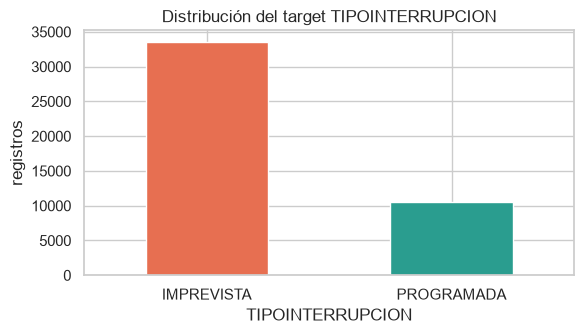

In [4]:
conteo_target = df["TIPOINTERRUPCION"].value_counts()
print(conteo_target)
print((conteo_target / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(6, 3.5))
colores_target = {"IMPREVISTA": "#e76f51", "PROGRAMADA": "#2a9d8f"}
conteo_target.plot(kind="bar", color=[colores_target[c] for c in conteo_target.index], ax=ax)
ax.set_title("Distribución del target TIPOINTERRUPCION")
ax.set_ylabel("registros")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

El target está desbalanceado **76.1% IMPREVISTA / 23.9% PROGRAMADA** — esto
condiciona la elección de métricas (F1 y recall de la clase minoritaria, no
accuracy) y el uso de `class_weight`/SMOTE en el notebook 03.

### 1.2 Duración de los cortes: histograma, boxplot y outliers 1.5·IQR

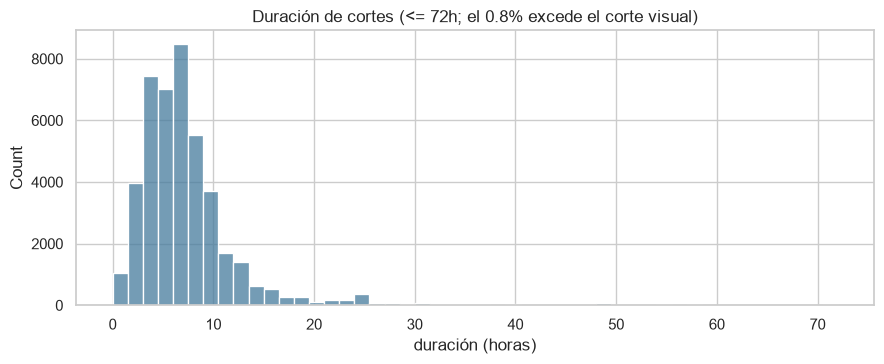

registros con duracion > 72h: 370 (0.8%)


In [5]:
UMBRAL_VISUAL_H = 72
pct_sobre_umbral = (df["duracion_horas"] > UMBRAL_VISUAL_H).mean() * 100

fig, ax = plt.subplots(figsize=(9, 3.8))
sns.histplot(df.loc[df["duracion_horas"] <= UMBRAL_VISUAL_H, "duracion_horas"],
             bins=48, color="#457b9d", ax=ax)
ax.set_title(f"Duración de cortes (<= {UMBRAL_VISUAL_H}h; el {pct_sobre_umbral:.1f}% excede el corte visual)")
ax.set_xlabel("duración (horas)")
plt.tight_layout()
plt.show()
print(f"registros con duracion > {UMBRAL_VISUAL_H}h: {(df['duracion_horas'] > UMBRAL_VISUAL_H).sum()} ({pct_sobre_umbral:.1f}%)")

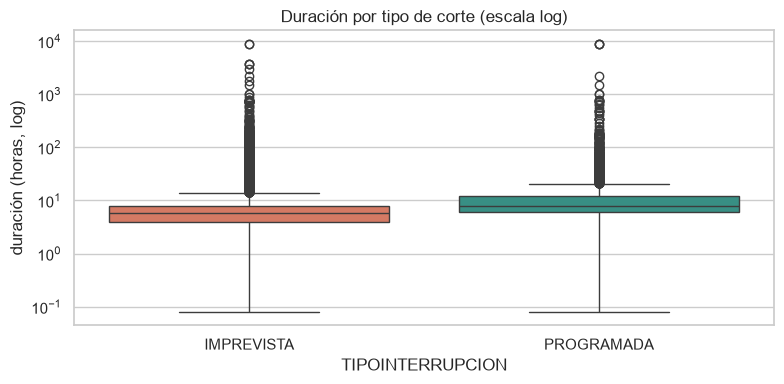

                   mean  median
TIPOINTERRUPCION               
IMPREVISTA         9.24    5.67
PROGRAMADA        14.84    8.00


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
datos_box = df[df["duracion_horas"] > 0]  # log no admite ceros
sns.boxplot(data=datos_box, x="TIPOINTERRUPCION", y="duracion_horas",
            hue="TIPOINTERRUPCION", palette=colores_target, legend=False, ax=ax)
ax.set_yscale("log")
ax.set_title("Duración por tipo de corte (escala log)")
ax.set_ylabel("duración (horas, log)")
plt.tight_layout()
plt.show()
print(df.groupby("TIPOINTERRUPCION")["duracion_horas"].agg(["mean", "median"]).round(2))

In [7]:
q1, q3 = df["duracion_horas"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_superior = q3 + FACTOR_IQR * iqr
outliers = df[df["duracion_horas"] > lim_superior]
print(f"Q1={q1:.1f}h  Q3={q3:.1f}h  IQR={iqr:.1f}h  limite superior={lim_superior:.1f}h")
print(f"outliers de duracion: {len(outliers)} registros ({len(outliers)/len(df)*100:.1f}%)")
print("\nTop 5 cortes mas largos:")
print(outliers.nlargest(5, "duracion_horas")[["EPS", "DISTRITO", "TIPOINTERRUPCION", "duracion_horas"]].to_string(index=False))

Q1=4.0h  Q3=8.6h  IQR=4.6h  limite superior=15.4h
outliers de duracion: 2969 registros (6.7%)

Top 5 cortes mas largos:
             EPS          DISTRITO TIPOINTERRUPCION  duracion_horas
         SEDAPAL         SURQUILLO       IMPREVISTA          8886.0
         SEDAPAL SANTIAGO DE SURCO       IMPREVISTA          8838.5
EMAPA SAN MARTIN         CASPISAPA       PROGRAMADA          8764.0
EMAPA SAN MARTIN          PUCACACA       PROGRAMADA          8764.0
EMAPA SAN MARTIN            PICOTA       PROGRAMADA          8764.0


La duración es **fuertemente asimétrica**: la mayoría de cortes dura horas, pero
existen outliers de semanas o meses (máximo ≈ 8,886 h ≈ 370 días). Por eso en la
matriz de distritos usamos la **mediana** además de la media, y en el clustering
la severidad se mide con la mediana. Este es el material de "complicación →
resolución" del informe (outliers → mediana/IQR, no eliminarlos: son cortes reales).

### 1.3 Mapa de correlación

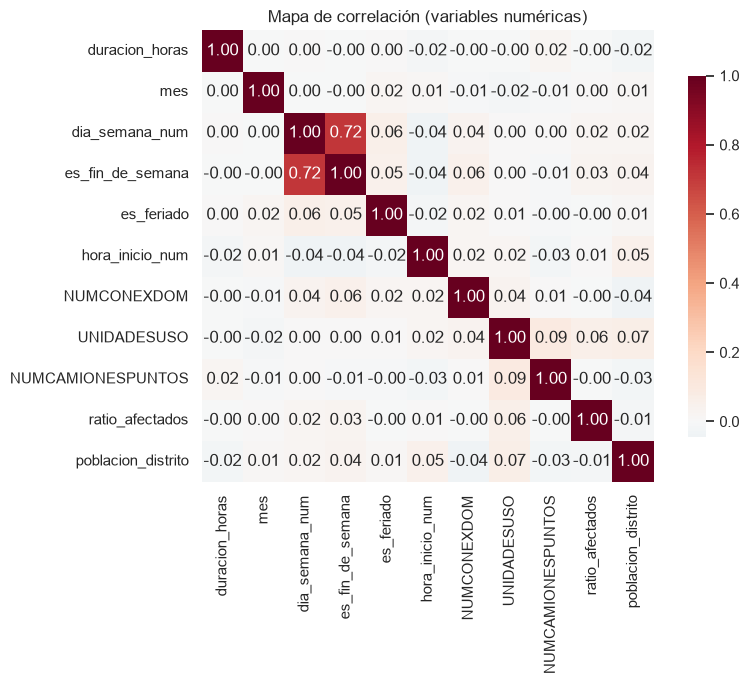

In [8]:
cols_corr = ["duracion_horas", "mes", "dia_semana_num", "es_fin_de_semana", "es_feriado",
             "hora_inicio_num", "NUMCONEXDOM", "UNIDADESUSO", "NUMCAMIONESPUNTOS",
             "ratio_afectados", "poblacion_distrito"]
corr = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Mapa de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

### 1.4 ¿Cuándo ocurren los cortes? (hora, día, mes)

La franja horaria y el día son señal predictiva fuerte: de noche el **95.0%** de
los cortes es imprevisto y de madrugada el **87.9%** (nadie programa un corte a
esas horas); en fin de semana los imprevistos suben a **85.9%** vs 73.9% de
lunes a viernes. Estas variables entran al clasificador del notebook 03.

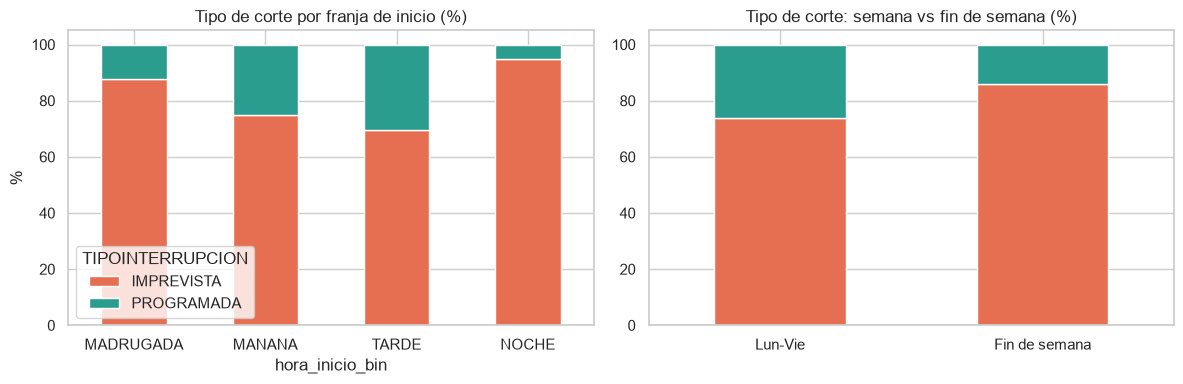

TIPOINTERRUPCION  IMPREVISTA  PROGRAMADA
hora_inicio_bin                         
MADRUGADA               87.9        12.1
MANANA                  75.0        25.0
TARDE                   69.5        30.5
NOCHE                   95.0         5.0
TIPOINTERRUPCION  IMPREVISTA  PROGRAMADA
Lun-Vie                 73.9        26.1
Fin de semana           85.9        14.1


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orden_bin = ["MADRUGADA", "MANANA", "TARDE", "NOCHE"]
tabla_hora = pd.crosstab(df["hora_inicio_bin"], df["TIPOINTERRUPCION"], normalize="index").loc[orden_bin] * 100
tabla_hora.plot(kind="bar", stacked=True, color=[colores_target[c] for c in tabla_hora.columns],
                ax=axes[0], legend=True)
axes[0].set_title("Tipo de corte por franja de inicio (%)")
axes[0].set_ylabel("%")
axes[0].tick_params(axis="x", rotation=0)

tabla_finde = pd.crosstab(df["es_fin_de_semana"], df["TIPOINTERRUPCION"], normalize="index") * 100
tabla_finde.index = ["Lun-Vie", "Fin de semana"]
tabla_finde.plot(kind="bar", stacked=True, color=[colores_target[c] for c in tabla_finde.columns],
                 ax=axes[1], legend=False)
axes[1].set_title("Tipo de corte: semana vs fin de semana (%)")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
print(tabla_hora.round(1))
print(tabla_finde.round(1))

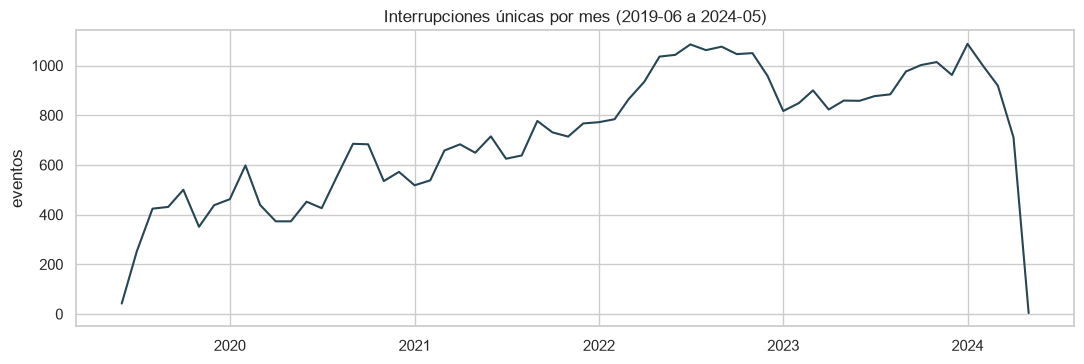

In [10]:
df["fecha_inicio_dt"] = pd.to_datetime(df["fecha_inicio"])
eventos_mes = df.groupby(df["fecha_inicio_dt"].dt.to_period("M"))["IDINTERRUPCION"].nunique()

fig, ax = plt.subplots(figsize=(11, 3.8))
eventos_mes.index = eventos_mes.index.to_timestamp()
ax.plot(eventos_mes.index, eventos_mes.values, color="#264653")
ax.set_title("Interrupciones únicas por mes (2019-06 a 2024-05)")
ax.set_ylabel("eventos")
plt.tight_layout()
plt.show()

### 1.5 Motivos y distritos: dónde está la señal (y el riesgo de leakage)

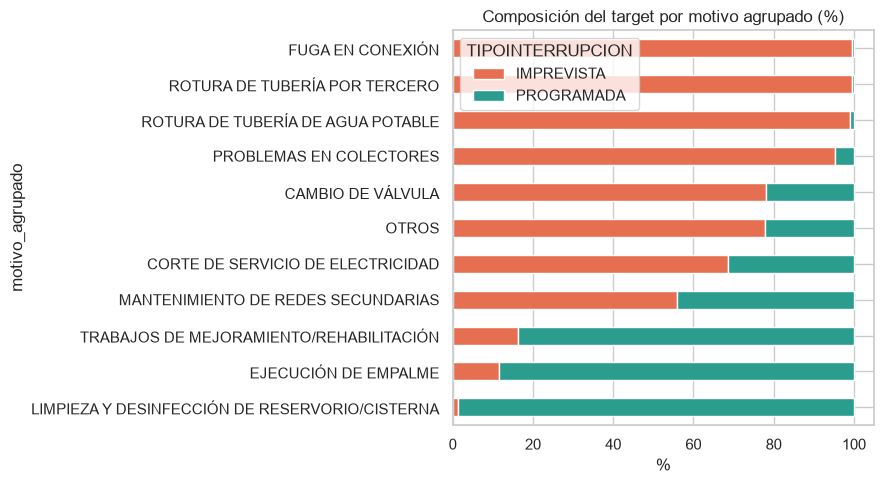

TIPOINTERRUPCION                                IMPREVISTA  PROGRAMADA
motivo_agrupado                                                       
LIMPIEZA Y DESINFECCIÓN DE RESERVORIO/CISTERNA         1.2        98.8
EJECUCIÓN DE EMPALME                                  11.4        88.6
TRABAJOS DE MEJORAMIENTO/REHABILITACIÓN               16.3        83.7
MANTENIMIENTO DE REDES SECUNDARIAS                    55.9        44.1
CORTE DE SERVICIO DE ELECTRICIDAD                     68.7        31.3
OTROS                                                 77.9        22.1
CAMBIO DE VÁLVULA                                     78.1        21.9
PROBLEMAS EN COLECTORES                               95.2         4.8
ROTURA DE TUBERÍA DE AGUA POTABLE                     99.0         1.0
ROTURA DE TUBERÍA POR TERCERO                         99.5         0.5
FUGA EN CONEXIÓN                                      99.6         0.4


In [11]:
tabla_motivo = (pd.crosstab(df["motivo_agrupado"], df["TIPOINTERRUPCION"], normalize="index") * 100)
tabla_motivo = tabla_motivo.sort_values("IMPREVISTA")

fig, ax = plt.subplots(figsize=(9, 5))
tabla_motivo.plot(kind="barh", stacked=True,
                  color=[colores_target[c] for c in tabla_motivo.columns], ax=ax)
ax.set_title("Composición del target por motivo agrupado (%)")
ax.set_xlabel("%")
plt.tight_layout()
plt.show()
print(tabla_motivo.round(1))

Varios motivos son **casi deterministas** respecto del target (una "ROTURA" es casi
siempre imprevista; un "MANTENIMIENTO" es casi siempre programado). El motivo sí se
conoce cuando la EPS reporta el corte, así que no es leakage temporal, pero puede
convertir el modelo en una tabla de búsqueda. En el notebook 03 se compara el
clasificador **con y sin `motivo_agrupado`** y se documenta la decisión.

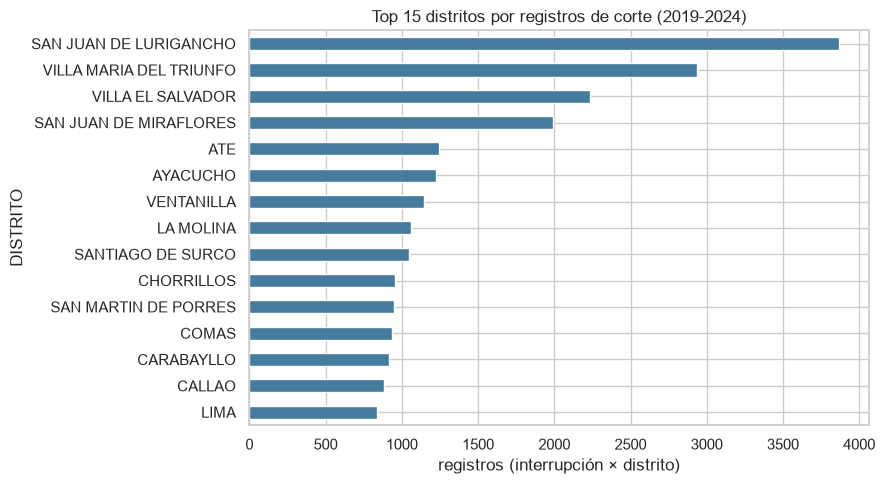

In [12]:
top_distritos = df[df["DISTRITO"] != "SIN DATO"]["DISTRITO"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 5))
top_distritos.sort_values().plot(kind="barh", color="#457b9d", ax=ax)
ax.set_title("Top 15 distritos por registros de corte (2019-2024)")
ax.set_xlabel("registros (interrupción × distrito)")
plt.tight_layout()
plt.show()

## 2. Clustering de distritos (K-means)

Se agrupan los **151 distritos con ≥30 registros** (`matriz_distritos.csv`) por su
**perfil de calidad de servicio**, no por su tamaño:

- `cortes_por_10k_hab` — frecuencia normalizada por población (comparable entre distritos)
- `duracion_mediana_h` — severidad típica (mediana, robusta a outliers)
- `pct_imprevistas` — gestión: qué fracción del problema es no planificada

`n_cortes` y `poblacion` quedan fuera a propósito: harían que el algoritmo agrupe
por tamaño del distrito en lugar de por calidad del servicio.

In [13]:
COLS_CLUSTER = ["cortes_por_10k_hab", "duracion_mediana_h", "pct_imprevistas"]

matriz_cl = matriz.dropna(subset=COLS_CLUSTER).copy()
print(f"distritos para clustering: {len(matriz_cl)} (excluidos {len(matriz) - len(matriz_cl)} sin poblacion INEI)")
print("\nAsimetria (skew) de las features:")
print(matriz_cl[COLS_CLUSTER].skew().round(2))

distritos para clustering: 151 (excluidos 0 sin poblacion INEI)

Asimetria (skew) de las features:
cortes_por_10k_hab    2.33
duracion_mediana_h    2.60
pct_imprevistas      -1.00
dtype: float64


In [14]:
# cortes_por_10k_hab y duracion_mediana_h tienen cola larga a la derecha: sin log,
# los pocos distritos extremos dominarian la distancia euclidea del K-means.
COLS_LOG = ["cortes_por_10k_hab", "duracion_mediana_h"]

X_cluster = matriz_cl[COLS_CLUSTER].copy()
for col in COLS_LOG:
    X_cluster[col] = np.log1p(X_cluster[col])

escalador = StandardScaler()
X_esc = escalador.fit_transform(X_cluster)
print("matriz estandarizada:", X_esc.shape)

matriz estandarizada: (151, 3)


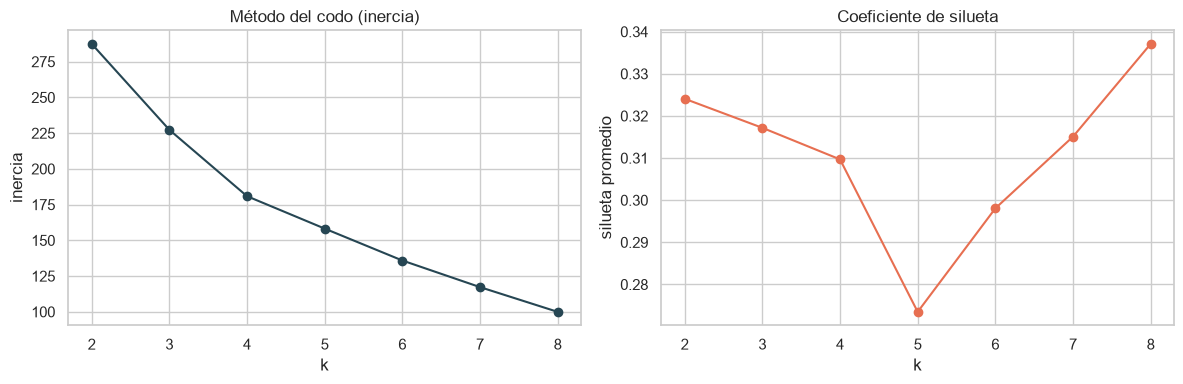

k | inercia | silueta
2 |    287.4 | 0.324
3 |    227.3 | 0.317
4 |    180.9 | 0.310
5 |    158.2 | 0.273
6 |    135.9 | 0.298
7 |    117.3 | 0.315
8 |     99.9 | 0.337


In [15]:
inercias, siluetas = [], []
rango_k = range(K_MIN, K_MAX + 1)
for k in rango_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    etiquetas_k = km.fit_predict(X_esc)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_esc, etiquetas_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(rango_k), inercias, "o-", color="#264653")
axes[0].set_title("Método del codo (inercia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inercia")
axes[1].plot(list(rango_k), siluetas, "o-", color="#e76f51")
axes[1].set_title("Coeficiente de silueta")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silueta promedio")
plt.tight_layout()
plt.show()

print("k | inercia | silueta")
for k, ine, sil in zip(rango_k, inercias, siluetas):
    print(f"{k} | {ine:8.1f} | {sil:.3f}")

**Elección de k = 4**: el **codo** de la inercia está en k=4 — la ganancia por
cluster adicional cae a la mitad después de ahí (60 → 46 → 23 → 22 → 19 → 17).
La **silueta** es plana en todo el rango (0.27–0.34): sus máximos están en k=8
(0.337) y k=2 (0.324), pero 8 clusters sobre 151 distritos pulveriza la
segmentación y 2 es demasiado grueso para ser accionable. k=4 combina el codo con
una silueta de **0.310** (a 0.027 del máximo) y produce 4 perfiles interpretables
(ver tabla siguiente) — criterio: evidencia numérica + utilidad de la segmentación.

In [16]:
km_final = KMeans(n_clusters=K_CLUSTERS, n_init=10, random_state=RANDOM_STATE)
matriz_cl["cluster"] = km_final.fit_predict(X_esc)
sil_final = silhouette_score(X_esc, matriz_cl["cluster"])
print(f"k = {K_CLUSTERS} | silueta = {sil_final:.3f}")
print("\nDistritos por cluster:")
print(matriz_cl["cluster"].value_counts().sort_index())

k = 4 | silueta = 0.310

Distritos por cluster:
cluster
0    57
1    24
2    53
3    17
Name: count, dtype: int64


In [17]:
perfil = matriz_cl.groupby("cluster").agg(
    n_distritos=("DISTRITO", "count"),
    cortes_por_10k_hab=("cortes_por_10k_hab", "mean"),
    duracion_mediana_h=("duracion_mediana_h", "mean"),
    pct_imprevistas=("pct_imprevistas", "mean"),
    n_cortes_prom=("n_cortes", "mean"),
    poblacion_prom=("poblacion", "mean"),
).round(1)
print(perfil.to_string())

print("\nEjemplos de distritos por cluster:")
for c in sorted(matriz_cl["cluster"].unique()):
    ejemplos = matriz_cl[matriz_cl["cluster"] == c].nlargest(4, "n_cortes")["DISTRITO"].tolist()
    print(f"  cluster {c}: {', '.join(ejemplos)}")

         n_distritos  cortes_por_10k_hab  duracion_mediana_h  pct_imprevistas  n_cortes_prom  poblacion_prom
cluster                                                                                                     
0                 57                53.2                 5.1             82.7          465.3        108949.9
1                 24                18.2                17.8             74.3           57.3         64217.9
2                 53                14.2                 6.3             66.3          235.1        149574.9
3                 17                12.3                11.3             25.4          106.6        121110.9

Ejemplos de distritos por cluster:
  cluster 0: SAN JUAN DE LURIGANCHO, VILLA MARIA DEL TRIUNFO, VILLA EL SALVADOR, SAN JUAN DE MIRAFLORES
  cluster 1: TUMBES, PIURA, BAGUA GRANDE, PAITA
  cluster 2: ATE, VENTANILLA, SAN MARTIN DE PORRES, COMAS
  cluster 3: INDEPENDENCIA, LURIGANCHO, TRUJILLO, JAEN


**Nombres interpretables** (a partir del perfil impreso arriba):

| Cluster | n | Perfil | Nombre |
| --- | --- | --- | --- |
| 0 | 57 | 53 cortes/10k hab, mediana 5.1h, 83% imprevistas | **"Sed crónica": frecuente, breve y reactivo** (SJL, VMT, VES, SJM) |
| 1 | 24 | 18 cortes/10k, mediana **17.8h**, 74% imprevistas | **"Crítico": cortes largos e imprevistos** (Tumbes, Piura, Paita) |
| 2 | 53 | 14 cortes/10k, mediana 6.3h, 66% imprevistas | **"Moderado": problema contenido** (Ate, Ventanilla, Comas) |
| 3 | 17 | 12 cortes/10k, mediana 11.3h, solo **25% imprevistas** | **"Planificado": predominan mantenimientos programados** (Trujillo, Jaén) |

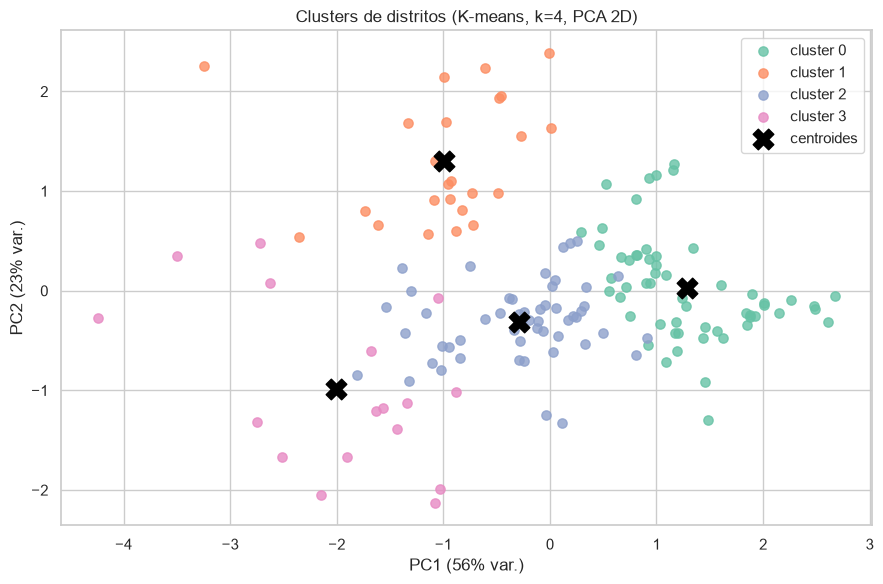

In [18]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_esc)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 6))
paleta = sns.color_palette("Set2", K_CLUSTERS)
for c in sorted(matriz_cl["cluster"].unique()):
    mascara = (matriz_cl["cluster"] == c).to_numpy()
    ax.scatter(coords[mascara, 0], coords[mascara, 1], s=45, alpha=0.8,
               color=paleta[c], label=f"cluster {c}")
centroides_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1], marker="X", s=220,
           c="black", label="centroides")
ax.set_xlabel(f"PC1 ({var_exp[0]:.0f}% var.)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.0f}% var.)")
ax.set_title(f"Clusters de distritos (K-means, k={K_CLUSTERS}, PCA 2D)")
ax.legend()
plt.tight_layout()
plt.show()

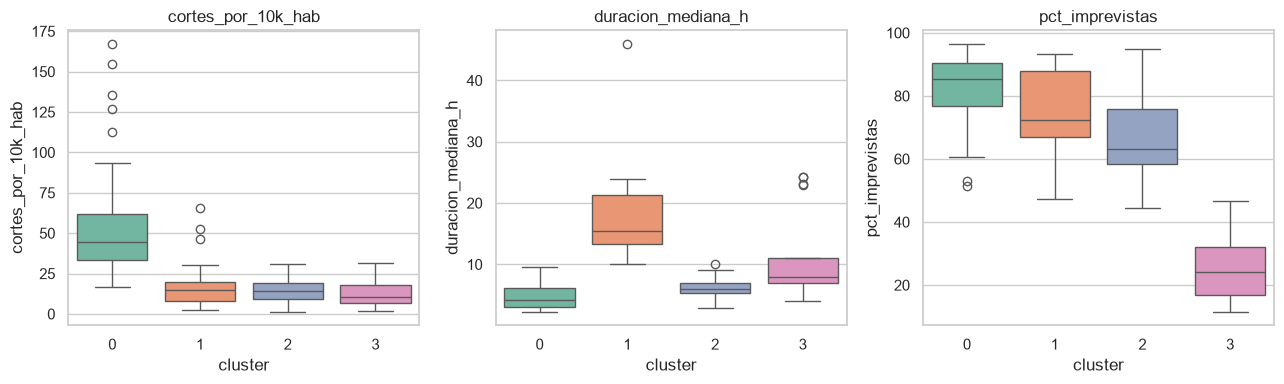

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, COLS_CLUSTER):
    sns.boxplot(data=matriz_cl, x="cluster", y=col, hue="cluster",
                palette=paleta, legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 3. DBSCAN (opcional): distritos atípicos

DBSCAN no exige fijar k y marca como **ruido (-1)** los puntos que no alcanzan
densidad mínima: sirve para detectar distritos-outlier que K-means forzaría dentro
de algún cluster.

In [20]:
db = DBSCAN(eps=EPS_DBSCAN, min_samples=MIN_SAMPLES_DBSCAN)
matriz_cl["cluster_dbscan"] = db.fit_predict(X_esc)
print(matriz_cl["cluster_dbscan"].value_counts().sort_index())

atipicos = matriz_cl[matriz_cl["cluster_dbscan"] == -1]
print(f"\nDistritos atipicos (ruido DBSCAN): {len(atipicos)}")
print(atipicos[["DEPARTAMENTO", "DISTRITO"] + COLS_CLUSTER].sort_values(
    "cortes_por_10k_hab", ascending=False).to_string(index=False))

cluster_dbscan
-1     23
 0    128
Name: count, dtype: int64

Distritos atipicos (ruido DBSCAN): 23
 DEPARTAMENTO            DISTRITO  cortes_por_10k_hab  duracion_mediana_h  pct_imprevistas
MADRE DE DIOS         LAS PIEDRAS              167.19                4.00             52.9
   SAN MARTIN            PUCACACA              135.75                7.17             51.5
       TUMBES         SAN JACINTO               65.49               18.00             75.4
       TUMBES CANOAS DE PUNTA SAL               52.63               23.75             73.3
       TUMBES             LA CRUZ               46.59               22.50             90.9
     AMAZONAS               BAGUA               31.43                9.00             19.5
     AREQUIPA            MOLLENDO               29.99               21.00             60.6
       TUMBES            ZORRITOS               26.59               24.00             85.3
  LA LIBERTAD               MOCHE               20.59               23.17        

In [21]:
salida = RUTA_PROCESSED / "matriz_distritos_clusters.csv"
matriz_cl.to_csv(salida, index=False)
print("guardado:", salida.name, "|", matriz_cl.shape)

guardado: matriz_distritos_clusters.csv | (151, 14)


## Conclusiones (material para el informe)

- El target 76/24 y los outliers extremos de duración (6.7% de registros sobre el
  límite 1.5·IQR de 15.4h; máximo 8,886h) son las dos complicaciones estructurales;
  se resuelven con métricas robustas (mediana, F1) y manejo de desbalance en el 03.
- Señal temporal fuerte: NOCHE 95% imprevistas, MADRUGADA 88%, fin de semana 86%.
- Los motivos casi deterministas (ROTURA 99% imprevista, LIMPIEZA 98.8% programada)
  anticipan la discusión de leakage del Panel 2.
- K-means con **k=4** (codo en 4, silueta 0.310) segmenta 151 distritos en:
  "sed crónica" (57), "crítico" (24), "moderado" (53) y "planificado" (17).
- DBSCAN marca 23 distritos atípicos (ej. Las Piedras con 167 cortes/10k hab,
  Nuevo Chimbote con mediana de 46h) que K-means forzaría dentro de un cluster.